# Final Corpus Classification — GPT-5.4-mini (v1)

Batch classification of the final corpus using a single API call per corpus type to minimise token usage.

> **Note:** The standard / irony / obfuscated splits share identical test sets within each corpus type. Classification is therefore run once per corpus type (raw-corpus and pre-filtered-corpus).

## Dependencies

In [1]:
import os
import re

from openai import OpenAI

import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import watermark

%load_ext watermark
%matplotlib inline

plt.style.use('../style.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
%watermark -n -v -m -iv

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.4.0

Compiler    : Clang 16.0.0 (clang-1600.0.26.6)
OS          : Darwin
Release     : 25.5.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

matplotlib: 3.10.5
pandas    : 2.3.1
openai    : 1.99.6
re        : 2.2.1
sklearn   : 1.7.1
watermark : 2.5.0
seaborn   : 0.13.2



## OpenAI client

In [3]:
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

## Batch classifier

Sends **all tweets in a single API call**. The response is a numbered list (`1. POSITIVE`, `2. NEGATIVE`, …) that is parsed back to a Series.

In [4]:
SYSTEM_MSG = "Sos un clasificador binario de tweets que hablan sobre drogas ilícitas"

CRITERIA = """\
    Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

    POSITIVE: cumple con uno o más de los siguientes:
    - El usuario del tweet habla de cómo o qué tipo de droga ilícita está consumiendo.
    - El usuario del tweet expresa la necesidad de consumir drogas ilícitas, ya sea por abstinencia o por gusto.
    - El usuario añora consumir drogas ilícitas.

    NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
    - Habla sobre noticias o información general sobre drogas ilícitas.
    - Menciona drogas ilícitas sin relación con consumo problemático o necesidad.
    - Expresa ironía o sarcasmo relacionado con drogas ilícitas."""

def build_batch_prompt(tweets: list[str]) -> str:
    numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(tweets))
    return (
        CRITERIA
        + "\n\n"
        + "Responde con una lista numerada, exactamente una clasificación por línea, "
        + "únicamente la palabra POSITIVE o NEGATIVE (sin puntuación adicional ni explicaciones):\n\n"
        + numbered
    )

def parse_batch_response(response_text: str, n: int) -> list[str]:
    lines = [l.strip() for l in response_text.strip().splitlines() if l.strip()]
    results = []
    for line in lines:
        # strip optional leading "N." or "N)"
        cleaned = re.sub(r"^\d+[.)\s]+", "", line).strip().upper().rstrip(".")
        if cleaned in ("POSITIVE", "NEGATIVE"):
            results.append(cleaned)
    if len(results) != n:
        raise ValueError(f"Expected {n} classifications, got {len(results)}. Response:\n{response_text}")
    return results

def classify_batch(tweets: list[str]) -> list[str]:
    prompt = build_batch_prompt(tweets)
    response = client.chat.completions.create(
        model="gpt-5.4-mini",
        messages=[
            {"role": "system", "content": SYSTEM_MSG},
            {"role": "user", "content": prompt},
        ],
        temperature=1,
    )
    return parse_batch_response(response.choices[0].message.content, len(tweets))

## Corpus types

Each entry is `(label, path_to_test_csv, output_prefix)`.

In [5]:
CORPORA = [
    ("raw-corpus",           "../data/raw/final-corpus/raw-corpus/standard/test.csv",           f"raw-corpus_v1"),
    ("pre-filtered-corpus",  "../data/raw/final-corpus/pre-filtered-corpus/standard/test.csv",  f"pre-filtered-corpus_v1"),
]


## Run batch classification

In [6]:
results = {}

for corpus_label, csv_path, out_prefix in CORPORA:
    print(f"\n{'='*60}")
    print(f"Corpus: {corpus_label}")
    print(f"{'='*60}")

    df = pd.read_csv(csv_path)
    tweets = df["text"].tolist()
    labels = df["label"].tolist()

    print(f"Tweets to classify: {len(tweets)}")

    predictions = classify_batch(tweets)
    df["prediction"] = predictions

    results[corpus_label] = df
    print(f"Done. Predictions: {df['prediction'].value_counts().to_dict()}")


Corpus: raw-corpus
Tweets to classify: 450


Done. Predictions: {'POSITIVE': 269, 'NEGATIVE': 181}

Corpus: pre-filtered-corpus
Tweets to classify: 450


Done. Predictions: {'POSITIVE': 271, 'NEGATIVE': 179}


## Metrics per corpus


Corpus: raw-corpus


/var/folders/d7/53rh3m0d4j983v3p54wjrlf80000gn/T/ipykernel_75737/3249787319.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


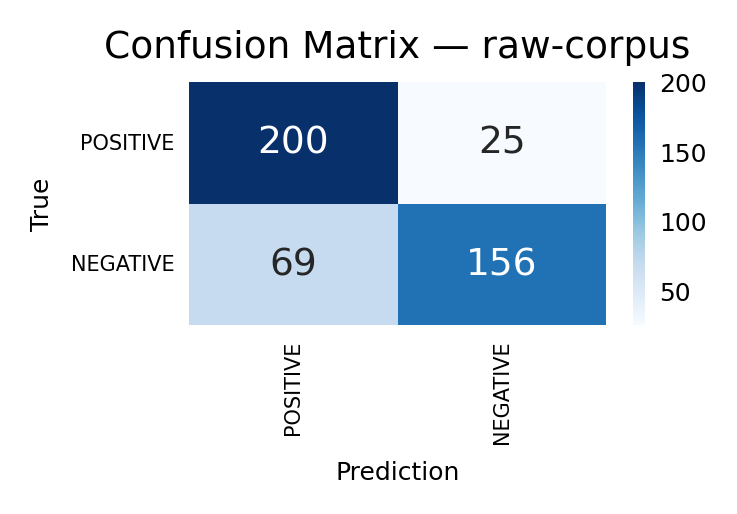

[[200  25]
 [ 69 156]]

Classification report:


,precision,recall,f1-score,support
POSITIVE,0.74,0.89,0.81,225
NEGATIVE,0.86,0.69,0.77,225
accuracy,0.79,0.79,0.79,1
macro avg,0.80,0.79,0.79,450
weighted avg,0.80,0.79,0.79,450



Wrongly classified: 94


,text,label,prediction
7,Mi mamá me pidió que piense en mi futuro y aba...,NEGATIVE,POSITIVE
8,Menos mal me da por cocinar y comer y no por i...,NEGATIVE,POSITIVE
12,Arranque carmel e inyectarme heroina era más s...,NEGATIVE,POSITIVE
23,Lauren conto que su experiencia al fumarse un ...,NEGATIVE,POSITIVE
30,papa me dice:voy salir un rato y le dije bueno...,NEGATIVE,POSITIVE
...,...,...,...
436,Soñé que me fumaba un porro con Robert Eggers ...,NEGATIVE,POSITIVE
437,@lightbluejoji es un buen momento para tomarme...,NEGATIVE,POSITIVE
438,"Voy a tener que empezar a tomar merca, no pued...",NEGATIVE,POSITIVE
448,#PorVos dejo de inyectarme heroína,POSITIVE,NEGATIVE



Corpus: pre-filtered-corpus


/var/folders/d7/53rh3m0d4j983v3p54wjrlf80000gn/T/ipykernel_75737/3249787319.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


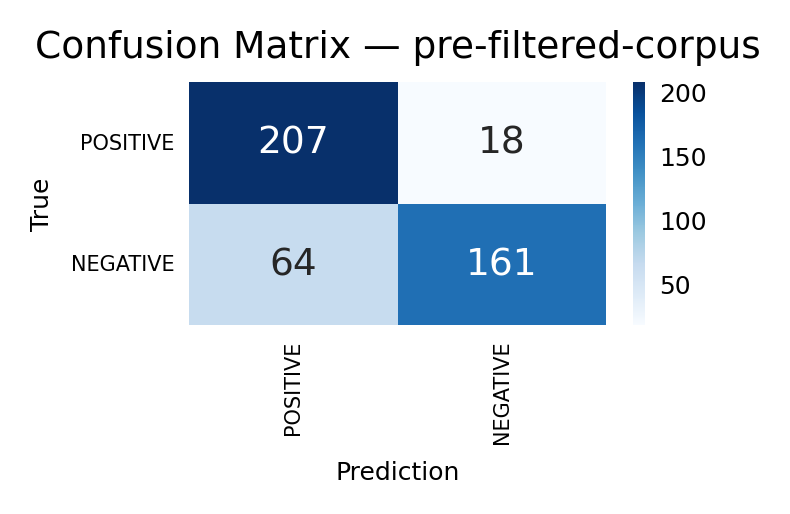

[[207  18]
 [ 64 161]]

Classification report:


,precision,recall,f1-score,support
POSITIVE,0.76,0.92,0.83,225
NEGATIVE,0.90,0.72,0.80,225
accuracy,0.82,0.82,0.82,1
macro avg,0.83,0.82,0.82,450
weighted avg,0.83,0.82,0.82,450



Wrongly classified: 82


,text,label,prediction
1,Y entonces en confesiones con el psicólogo le...,NEGATIVE,POSITIVE
12,Se graban fumandose un porro 🤡,NEGATIVE,POSITIVE
19,anoche compré un porro y lo perdí. F,POSITIVE,NEGATIVE
22,Mamá he visto a Whispers a los ojos y si no es...,NEGATIVE,POSITIVE
29,yo prefiero inyectarme heroína caliente para e...,NEGATIVE,POSITIVE
...,...,...,...
409,Necesito éxtasis de futbol,NEGATIVE,POSITIVE
418,Ya no vuelvo a inyectarme heroína borracho. :(,POSITIVE,NEGATIVE
426,"Armé un porro tan lindo, que me da pena quemarlo.",POSITIVE,NEGATIVE
433,Hoy me di cuenta de que me puedo auto-ligar el...,POSITIVE,NEGATIVE


In [7]:
LABELS = ["POSITIVE", "NEGATIVE"]

for corpus_label, _, out_prefix in CORPORA:
    df = results[corpus_label]
    y_true = df["label"]
    y_pred = df["prediction"]

    print(f"\n{'='*60}")
    print(f"Corpus: {corpus_label}")
    print(f"{'='*60}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(2, 1))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                cbar=True, annot_kws={"size": 9}, ax=ax)
    ax.collections[0].colorbar.ax.tick_params(labelsize=6)
    ax.set_xlabel("Prediction", fontsize=6)
    ax.set_ylabel("True", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_title(f"Confusion Matrix — {corpus_label}", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(cm)

    # Classification report
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nClassification report:")
    display(report_df.style.format({"precision": "{:.2f}", "recall": "{:.2f}", "f1-score": "{:.2f}", "support": "{:.0f}"}))

    # Errors
    df["error"] = df["label"] != df["prediction"]
    errors = df[df["error"]][["text", "label", "prediction"]]
    print(f"\nWrongly classified: {len(errors)}")
    display(errors)

## Save wrongly-classified tweets

In [8]:
for corpus_label, _, out_prefix in CORPORA:
    df = results[corpus_label]
    errors = df[df["label"] != df["prediction"]][["text", "label", "prediction"]]
    out_path = f"../data/processed/final-corpus/{corpus_label}/wct_gpt-5.4-mini-v1.csv"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    errors.to_csv(out_path, index=False)
    print(f"Saved {len(errors)} errors → {out_path}")

Saved 94 errors → ../data/processed/final-corpus/raw-corpus/wct_gpt-5.4-mini-v1.csv
Saved 82 errors → ../data/processed/final-corpus/pre-filtered-corpus/wct_gpt-5.4-mini-v1.csv
